# Ryszard Budzisz Lab 1

In [16]:
from abc import ABC, abstractmethod

class StepRule(ABC):
    @abstractmethod
    def next_step(self, previous_step, simulation_parameters):
        pass

class StepAnalyzer(ABC):
    @abstractmethod
    def analyze(self, previous_step, simulation_parameters):
        pass

class FinalAnalyzer(ABC):
    @abstractmethod
    def final(self, previous_step, simulation_parameters):
        pass

class Visualizer(ABC):
    @abstractmethod
    def visualize(self, previous_step, simulation_parameters):
        pass

In [17]:
from dataclasses import dataclass

@dataclass
class OscConfig:
    liczba_krokow: int
    t: float # krok czasowy
    m: float
    k: float
    x_0: float
    v_0: float

@dataclass
class OscState:
    numer_kroku: int = 0
    czas: float = 0
    x: float = 0
    v: float = 0
    a: float = 0

@dataclass
class OscStatistics:
    energia_k: float
    energia_p: float

@dataclass
class OscFinalStatistics:
    x_max: float = 0
    v_max: float = 0
    a_max: float = 0

@dataclass
class OscResult:
    konfiguracja: str
    lista_stanow: list
    lista_statystyk: list
    statystyki_koncowe: OscFinalStatistics


In [18]:
import matplotlib.pyplot as plt

class OscRule(StepRule):
    def next_step(self, previous_step, simulation_parameters):
        next_state = OscState()
        next_state.numer_kroku = 1 + previous_step.numer_kroku
        next_state.czas = next_state.numer_kroku * simulation_parameters.t
        next_state.x = previous_step.x + previous_step.v * simulation_parameters.t
        next_state.v = previous_step.v + previous_step.a * simulation_parameters.t
        next_state.a = - simulation_parameters.k * next_state.x / simulation_parameters.m
        return next_state

class OscAnalyzer(StepAnalyzer):
    def analyze(self, previous_step, simulation_parameters):
        k = simulation_parameters.m * previous_step.v ** 2 / 2
        p = simulation_parameters.k * previous_step.x ** 2 / 2
        stat = OscStatistics(k, p)
        return stat
        #return previous_step.numer_kroku, previous_step.czas, previous_step.x, previous_step.v, previous_step.a

class OscFinalAnalyzer(FinalAnalyzer): # do zrobienia
    def final(self, steps):
        last = OscFinalStatistics()
        for i in steps:
            if abs(i.x)> last.x_max:
                last.x_max = i.x
            if abs(i.v) > last.v_max:
                last.v_max = i.v
            if abs(i.a) > last.a_max:
                last.a_max = i.a
        return last
    
class OscVisualizer(Visualizer):
    def visualize(self, t, x):
        plt.plot(t, x, label='Wykres x(t)')
        plt.axhline(x[0], color='green', label='x = x(0)')
        plt.axhline(-x[0], color='green', label='x = -x(0)')
        plt.axhline(0, color='red', label='Zero')
        plt.xlabel('t')
        plt.ylabel('x')
        plt.legend()

In [19]:
class Simulation:
    def __init__(self, parameters, step_rule: StepRule, step_analyzer: StepAnalyzer, final_analyzer: FinalAnalyzer, visualizer: Visualizer):
        self.parameters = parameters
        self.step_rule = step_rule
        self.step_analyzer = step_analyzer
        self.final_analyzer = final_analyzer
        self.visualizer = visualizer
    
    def run(self, initial_step, num_steps):
        steps = [initial_step]
        X = [initial_step.x]
        T = [initial_step.czas]
        analysis = [self.step_analyzer.analyze(self, initial_step, self.parameters)]
        for _ in range(num_steps):
            next_step = self.step_rule.next_step(self, steps[-1], self.parameters)
            steps.append(next_step)
            analysis.append(self.step_analyzer.analyze(self, steps[-1], self.parameters))
            T.append(steps[-1].czas)
            X.append(steps[-1].x)
        finals = self.final_analyzer.final(self, steps)
        visual = self.visualizer.visualize(self, T, X)
        return OscResult('Oscylator harmoniczny', steps, analysis, finals)
        #return steps # lista wszytskich krokow

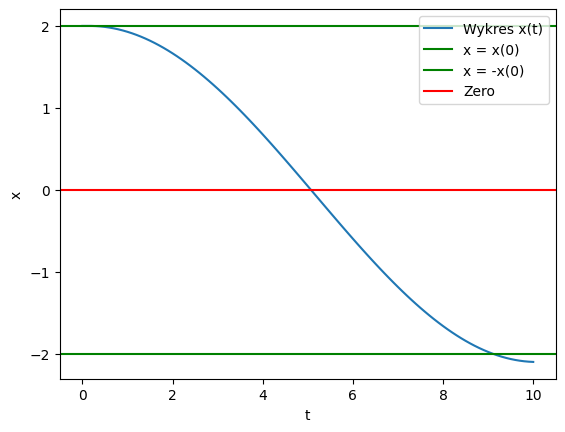

In [20]:
params = OscConfig(liczba_krokow=100, t=0.1, m=10, k=1, x_0=2, v_0=0)
test = Simulation(params, OscRule, OscAnalyzer, OscFinalAnalyzer, OscVisualizer)
wynik1 = test.run(OscState(x=params.x_0, v=params.v_0), params.liczba_krokow)

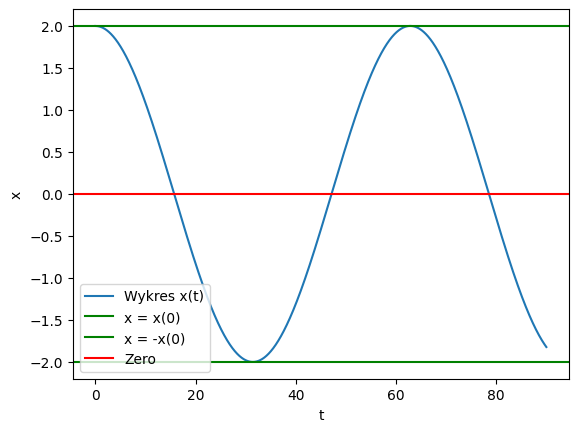

In [21]:
params = OscConfig(liczba_krokow=90000, t=0.001, m=100, k=1, x_0=2, v_0=0)
test = Simulation(params, OscRule, OscAnalyzer, OscFinalAnalyzer, OscVisualizer)
wynik2 = test.run(OscState(x=params.x_0, v=params.v_0), params.liczba_krokow)

In [22]:
wynik1.konfiguracja, wynik2.konfiguracja

('Oscylator harmoniczny', 'Oscylator harmoniczny')

In [23]:
wynik1.lista_stanow

[OscState(numer_kroku=0, czas=0, x=2, v=0, a=0),
 OscState(numer_kroku=1, czas=0.1, x=2.0, v=0.0, a=-0.2),
 OscState(numer_kroku=2, czas=0.2, x=2.0, v=-0.020000000000000004, a=-0.2),
 OscState(numer_kroku=3, czas=0.30000000000000004, x=1.998, v=-0.04000000000000001, a=-0.1998),
 OscState(numer_kroku=4, czas=0.4, x=1.994, v=-0.059980000000000006, a=-0.1994),
 OscState(numer_kroku=5, czas=0.5, x=1.988002, v=-0.07992, a=-0.1988002),
 OscState(numer_kroku=6, czas=0.6000000000000001, x=1.98001, v=-0.09980002, a=-0.198001),
 OscState(numer_kroku=7, czas=0.7000000000000001, x=1.970029998, v=-0.11960012, a=-0.1970029998),
 OscState(numer_kroku=8, czas=0.8, x=1.958069986, v=-0.13930041998, a=-0.1958069986),
 OscState(numer_kroku=9, czas=0.9, x=1.944139944002, v=-0.15888111984, a=-0.1944139944002),
 OscState(numer_kroku=10, czas=1.0, x=1.928251832018, v=-0.17832251928002, a=-0.1928251832018),
 OscState(numer_kroku=11, czas=1.1, x=1.910419580089998, v=-0.19760503760019998, a=-0.19104195800899978)

In [24]:
wynik2.lista_stanow

[OscState(numer_kroku=0, czas=0, x=2, v=0, a=0),
 OscState(numer_kroku=1, czas=0.001, x=2.0, v=0.0, a=-0.02),
 OscState(numer_kroku=2, czas=0.002, x=2.0, v=-2e-05, a=-0.02),
 OscState(numer_kroku=3, czas=0.003, x=1.99999998, v=-4e-05, a=-0.019999999799999998),
 OscState(numer_kroku=4, czas=0.004, x=1.99999994, v=-5.99999998e-05, a=-0.0199999994),
 OscState(numer_kroku=5, czas=0.005, x=1.99999988, v=-7.99999992e-05, a=-0.019999998800000002),
 OscState(numer_kroku=6, czas=0.006, x=1.9999998000000008, v=-9.9999998e-05, a=-0.01999999800000001),
 OscState(numer_kroku=7, czas=0.007, x=1.9999997000000027, v=-0.000119999996, a=-0.019999997000000026),
 OscState(numer_kroku=8, czas=0.008, x=1.9999995800000068, v=-0.00013999999300000004, a=-0.01999999580000007),
 OscState(numer_kroku=9, czas=0.009000000000000001, x=1.9999994400000138, v=-0.0001599999888000001, a=-0.019999994400000137),
 OscState(numer_kroku=10, czas=0.01, x=1.999999280000025, v=-0.00017999998320000022, a=-0.01999999280000025),
 O

In [25]:
wynik1.lista_statystyk

[OscStatistics(energia_k=0.0, energia_p=2.0),
 OscStatistics(energia_k=0.0, energia_p=2.0),
 OscStatistics(energia_k=0.002000000000000001, energia_p=2.0),
 OscStatistics(energia_k=0.008000000000000004, energia_p=1.996002),
 OscStatistics(energia_k=0.017988002000000003, energia_p=1.988018),
 OscStatistics(energia_k=0.031936032, energia_p=1.9760759760020001),
 OscStatistics(energia_k=0.049800219960002, energia_p=1.9602198000500002),
 OscStatistics(energia_k=0.071520943520072, energia_p=1.94050909650994),
 OscStatistics(energia_k=0.09702303503302193, energia_p=1.91701903503702),
 OscStatistics(energia_k=0.1262160512080622, energia_p=1.8898400609320498),
 OscStatistics(energia_k=0.1589946044118655, energia_p=1.8590775638403867),
 OscStatistics(energia_k=0.19523875442488225, energia_p=1.824851485995622),
 OscStatistics(energia_k=0.2348144592064621, energia_p=1.7872958714544627),
 OscStatistics(energia_k=0.2775740829833467, energia_p=1.746558358008239),
 OscStatistics(energia_k=0.32335695974

In [26]:
wynik2.lista_statystyk

[OscStatistics(energia_k=0.0, energia_p=2.0),
 OscStatistics(energia_k=0.0, energia_p=2.0),
 OscStatistics(energia_k=2.0000000000000004e-08, energia_p=2.0),
 OscStatistics(energia_k=8.000000000000001e-08, energia_p=1.99999996),
 OscStatistics(energia_k=1.7999999879999998e-07, energia_p=1.9999998800000016),
 OscStatistics(energia_k=3.1999999359999995e-07, energia_p=1.9999997600000072),
 OscStatistics(energia_k=4.999999800000002e-07, energia_p=1.9999996000000215),
 OscStatistics(energia_k=7.199999520000009e-07, energia_p=1.9999994000000505),
 OscStatistics(energia_k=9.799999020000032e-07, energia_p=1.9999991600001017),
 OscStatistics(energia_k=1.2799998208000078e-06, energia_p=1.9999988800001844),
 OscStatistics(energia_k=1.619999697600018e-06, energia_p=1.9999985600003092),
 OscStatistics(energia_k=1.9999995200000384e-06, energia_p=1.9999982000004888),
 OscStatistics(energia_k=2.419999274000074e-06, energia_p=1.999997800000737),
 OscStatistics(energia_k=2.879998944000134e-06, energia_p=

In [27]:
wynik1.statystyki_koncowe, wynik2.statystyki_koncowe

(OscFinalStatistics(x_max=-2.1012883923987355, v_max=-0.007961382475894712, a_max=0.21012883923987355),
 OscFinalStatistics(x_max=2.0006284184883567, v_max=-0.08247903150994604, a_max=0.018229982217627495))